<a href="https://colab.research.google.com/github/Yerra-Hansika/stock-price-predictor/blob/main/StockPricePredictor_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Fetching stock data...


/tmp/ipykernel_868/667873036.py:14: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download("AAPL", start="2020-01-01", end="2026-01-01")
[*********************100%***********************]  1 of 1 completed


Generating graph...


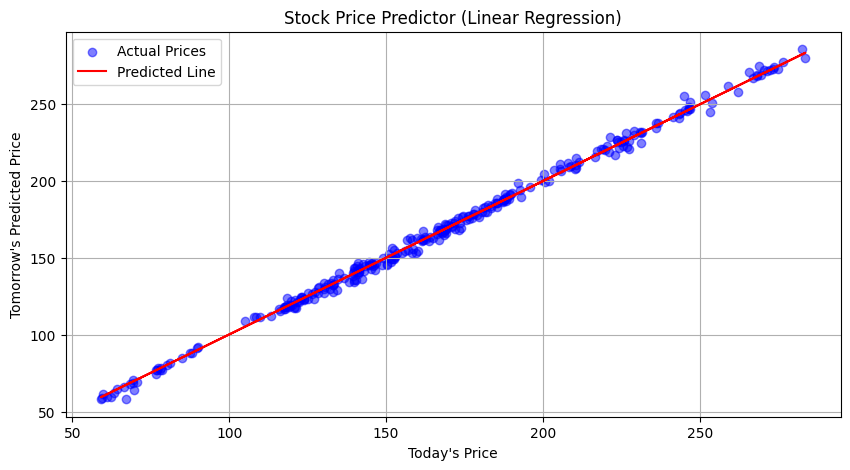


Last Closing Price: $271.36
Predicted Next Day Price: $271.15


In [1]:
# 1. Install the yfinance library (Google Colab handles the rest automatically!)
!pip install yfinance

# 2. Import the required libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split

# 3. Fetch Apple (AAPL) Stock Data
print("Fetching stock data...")
data = yf.download("AAPL", start="2020-01-01", end="2026-01-01")
data = data[["Close"]].copy()
data.columns = ["Close"]

# 4. Prepare Data for Machine Learning
data["Prediction"] = data[["Close"]].shift(-1)
X = np.array(data[["Close"]])[:-1]
y = np.array(data["Prediction"])[:-1]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 5. Train the Model
model = LinearRegression()
model.fit(X_train, y_train)

# 6. Generate the visual graph
print("Generating graph...")
plt.figure(figsize=(10, 5))
plt.scatter(X_test, y_test, color="blue", label="Actual Prices", alpha=0.5)
plt.plot(X_test, model.predict(X_test), color="red", label="Predicted Line")
plt.title("Stock Price Predictor (Linear Regression)")
plt.xlabel("Today's Price")
plt.ylabel("Tomorrow's Predicted Price")
plt.legend()
plt.grid(True)
plt.show()

# 7. Output Final Prediction
last_price = np.array([[data["Close"].iloc[-1]]])
future_pred = model.predict(last_price)
print(f"\nLast Closing Price: ${last_price[0][0]:.2f}")
print(f"Predicted Next Day Price: ${future_pred[0]:.2f}")